# FCC Invoices Dataset Import to S3 Vector store

This notebook demonstrates how to import the FCC invoices (REALKIE) dataset into S3 Vectors for use with the dynamic few-shot Lambda function.

The FCC invoices dataset contains invoice documents that can be used as few-shot examples for document extraction tasks.

This notebook can serve as an example on how to import other datasets with ground truth data into S3 Vectors.

## Process Overview:

1. **Load FCC Invoices Dataset** - Sync and load the dataset using load_dataset()
2. **Generate Embeddings** - Create multimodal embeddings using Amazon Nova
3. **Upload to S3 Vectors** - Store embeddings and metadata in S3 Vectors index
4. **Verify Import** - Test similarity search functionality

> **Note**: This notebook requires AWS credentials with permissions for Bedrock, S3, and S3 Vectors services.

# 1. Prerequisites and Configuration

Deploy the [Dynamic Few-Shot Prompting Lambda](../README.md) as per instructions.

Navigate to [CloudFormation](https://console.aws.amazon.com/cloudformation/home) in the AWS Console and go to the `IDP-dynamic-few-shot` stack that you deployed earlier. Click on the `Outputs` tab and take note of the following values:
* DatasetBucket
* VectorBucketName
* VectorIndexName
* ModelId
* VectorDimensions

Set the configuration below to reflect above values:

In [1]:
# Configuration - Update these values from the IDP-dynamic-few-shot stack in CloudFormation
DATASET_BUCKET = "<DatasetBucket>"
VECTOR_BUCKET_NAME = "<VectorBucketName>"
VECTOR_INDEX_NAME = "<VectorIndexName>"
MODEL_ID = "amazon.nova-2-multimodal-embeddings-v1:0"
VECTOR_DIMENSIONS = 3072

print(f"Configured for dataset S3 Bucket: {DATASET_BUCKET}")
print(f"Configured for S3 Vectors bucket: {VECTOR_BUCKET_NAME}")
print(f"Configured for S3 Vectors index: {VECTOR_INDEX_NAME}")
print(f"Using embedding model: {MODEL_ID}")
print(f"Using embedding dimensions: {VECTOR_DIMENSIONS}")

## 2. Install Dependencies

Install `idp_common` along with Python dependencies.

In [ ]:
# Let's make sure that modules are autoreloaded
%load_ext autoreload
%autoreload 2

ROOTDIR="../../../"
# First uninstall existing package (to ensure we get the latest version)
%pip uninstall -y idp_common

# Install the IDP common package with all components in development mode
%pip install -q -e "{ROOTDIR}/lib/idp_common_pkg[dev, all]"

# Note: We can also install specific components like:
# %pip install -q -e "{ROOTDIR}/lib/idp_common_pkg[ocr,classification,extraction,evaluation]"

# Check installed version
%pip show idp_common | grep -E "Version|Location"

# Install required packages
%pip install -q pillow tqdm pandas datasets matplotlib

# Optionally use a .env file fxor environment variables
try:
    from dotenv import load_dotenv
    load_dotenv()  
except ImportError:
    pass

## 3. Import Libraries and Initialize Clients

Create the S3 Vectors, S3 and Bedrock clients for further use.

In [ ]:
import json
import subprocess
from pathlib import Path
from typing import Dict, List, Any
from tqdm import tqdm
import pandas as pd
import io
import matplotlib.pyplot as plt
from PIL import Image as PILImage

import boto3
from datasets import load_dataset

# Import IDP common modules
from idp_common import bedrock, s3

# Initialize clients
s3vectors_client = boto3.client('s3vectors')
bedrock_client = bedrock.BedrockClient()

print("Clients initialized successfully")

## 5. Load FCC Invoices Dataset

This will download the fcc_invoices dataset from [RealKIE](https://github.com/IndicoDataSolutions/RealKIE). You can customize this to download your own dataset.

In [ ]:
# Sync FCC invoices dataset from S3
print("Syncing FCC invoices dataset from S3...")

# Create datasets directory
dataset_root_dir = Path('../datasets')
dataset_root_dir.mkdir(exist_ok=True)

# Dataset directory
dataset_dir = dataset_root_dir / 'fcc_invoices'

# Sync dataset from S3 using AWS CLI with Wasabi endpoint
if not dataset_dir.exists() or not any(dataset_dir.iterdir()):
    print("Syncing dataset from S3...")
    sync_command = [
        'aws', 's3', 'sync',
        's3://project-fruitfly/fcc_invoices',
        str(dataset_dir),
        '--endpoint-url=https://s3.us-east-2.wasabisys.com',
        '--no-sign-request'
    ]
    
    try:
        result = subprocess.run(sync_command, capture_output=True, text=True, check=True)
        print(f"Dataset synced successfully to {dataset_dir}")
        print(f"Sync output: {result.stdout}")
    except subprocess.CalledProcessError as e:
        print(f"Error syncing dataset: {e}")
        print(f"Error output: {e.stderr}")
        raise
else:
    print(f"Using existing dataset at {dataset_dir}")

Now load the training dataset and explore a sample document.

For the `CLASS_LABEL`, ensure that this matches one that is available in the IDP configuration.

In [5]:
# Configuration for this dataset (as per class definitions in the IDP configuration)
CLASS_LABEL = 'Invoice'

# Load the training dataset using load_dataset
print("Loading training dataset...")
try:
    # Load dataset from local directory
    dataset = load_dataset('csv', data_dir=str(dataset_dir), split='train')
    print(f"Loaded dataset with {len(dataset)} samples")
    
    # Show sample information
    if len(dataset) > 0:
        sample = dataset[0]
        print(f"Sample document: {json.dumps(sample, indent=2)}")

except Exception as e:
    print(f"Error loading dataset: {e}")
    # Fallback: list files in directory
    image_files = list(dataset_dir.glob('**/*.jpg')) + list(dataset_dir.glob('**/*.png'))
    print(f"Found {len(image_files)} image files in directory")
    if image_files:
        print(f"Sample image: {image_files[0].name}")
        print(f"Image file size: {image_files[0].stat().st_size} bytes")

print(f"Class label: {CLASS_LABEL}")

Loading training dataset...
Loaded dataset with 221 samples
Sample document: {
  "Unnamed: 0.2": 0,
  "Unnamed: 0": 0,
  "Unnamed: 0.1": 0,
  "document_path": "fcc_invoices/files/2dfd91c64c66a5a92b4eb1c46e26f87f.pdf",
  "image_files": "[\"fcc_invoices/images/2dfd91c64c66a5a92b4eb1c46e26f87f/page_0.png\", \"fcc_invoices/images/2dfd91c64c66a5a92b4eb1c46e26f87f/page_1.png\", \"fcc_invoices/images/2dfd91c64c66a5a92b4eb1c46e26f87f/page_2.png\", \"fcc_invoices/images/2dfd91c64c66a5a92b4eb1c46e26f87f/page_3.png\", \"fcc_invoices/images/2dfd91c64c66a5a92b4eb1c46e26f87f/page_4.png\", \"fcc_invoices/images/2dfd91c64c66a5a92b4eb1c46e26f87f/page_5.png\"]",
  "labels": "[{\"label\": \"Line Item - Description\", \"start\": 5069, \"end\": 5081, \"text\": \"IA* 11a -12p\"}, {\"label\": \"Line Item - Description\", \"start\": 5082, \"end\": 5095, \"text\": \"M -F 11a -12p\"}, {\"label\": \"Line Item - Days\", \"start\": 5175, \"end\": 5182, \"text\": \"MTWTF--\"}, {\"label\": \"Line Item - Rate\", \"st

## 6. Process Dataset and Generate Embeddings

This section defines various helper functions. If you adapt to your own dataset, you will need to modify the `parse_ground_truth_labels()` function to map attributes to the expected format.

The expected attribute list is configured in IDP for the given class and is configurable. Depending on your dataset, you might consider creating your own class with list of attributes.

The function `create_metadata()` then converts the attribute list to the metadata format for storing in S3 Vectors.

In [ ]:
def upload_image_to_s3(image_bytes: bytes, s3_key: str) -> str:
    """Upload image to S3 and return S3 URI."""
    s3.write_content(
        content=image_bytes,
        bucket=DATASET_BUCKET,
        key=s3_key
    )
    return f"s3://{DATASET_BUCKET}/{s3_key}"

def get_image_bytes_from_file(image_path):
    """Read image file directly as bytes."""
    with open(image_path, 'rb') as f:
        return f.read()

def parse_ground_truth_labels(labels_json_str: str) -> Dict:
    """Parse ground truth labels from the dataset and convert to expected format.
    
    Example output format:
    {
        "Agency": "Great American Media",
        "Advertiser": "ISS/HOUSE MAJ PAC", 
        "GrossTotal": 94700.00,
        "PaymentTerms": "Cash In Advance",
        "AgencyCommission": 14205.00,
        "NetAmountDue": 80495.00,
        "LineItems": [
            {
                "LineItemDescription": "TODAY IN FLORIDA @9PM",
                "LineItemStartDate": "10/18/2016", 
                "LineItemEndDate": null,
                "LineItemDays": ["T"],
                "LineItemRate": 500.00
            },
            {
                "LineItemDescription": "CH 7 NEWS @ 10PM",
                "LineItemStartDate": "10/18/2016",
                "LineItemEndDate": null, 
                "LineItemDays": ["T"],
                "LineItemRate": 3200.00
            }
        ]
    }
    """    
    try:
        labels = json.loads(labels_json_str)
    except (json.JSONDecodeError, TypeError):
        return None
    
    # Initialize the result structure
    result = {
        "Agency": None,
        "Advertiser": None,
        "GrossTotal": None,
        "PaymentTerms": None,
        "AgencyCommission": None,
        "NetAmountDue": None,
        "LineItems": []
    }
    
    # Group line items by their properties
    line_items = {}
    
    for label in labels:
        label_type = label.get('label', '')
        text = label.get('text', '')
        
        # Map top-level fields
        if label_type == 'Agency':
            result['Agency'] = text
        elif label_type == 'Advertiser':
            result['Advertiser'] = text
        elif label_type == 'Gross Total':
            try:
                result['GrossTotal'] = float(text.replace(',', '').replace('$', ''))
            except ValueError:
                result['GrossTotal'] = text
        elif label_type == 'Net Amount Due':
            try:
                result['NetAmountDue'] = float(text.replace(',', '').replace('$', ''))
            except ValueError:
                result['NetAmountDue'] = text
        elif label_type == 'Payment Terms':
            result['PaymentTerms'] = text
        elif label_type == 'Agency Commission':
            try:
                result['AgencyCommission'] = float(text.replace(',', '').replace('$', ''))
            except ValueError:
                result['AgencyCommission'] = text
        
        # Handle line items (group by position or create separate items)
        elif label_type.startswith('Line Item - '):
            field_name = label_type.replace('Line Item - ', '')
            start_pos = label.get('start', 0)
            
            # Use start position to group related line item fields
            # Find the closest line item group
            closest_key = None
            min_distance = float('inf')
            
            for key in line_items.keys():
                distance = abs(start_pos - key)
                if distance < min_distance and distance < 1000:  # Within reasonable range
                    min_distance = distance
                    closest_key = key
            
            if closest_key is None:
                closest_key = start_pos
                line_items[closest_key] = {}
            
            # Map field names to expected schema
            if field_name == 'Description':
                line_items[closest_key]['LineItemDescription'] = text
            elif field_name == 'Start Date':
                line_items[closest_key]['LineItemStartDate'] = text
            elif field_name == 'End Date':
                line_items[closest_key]['LineItemEndDate'] = text if text else None
            elif field_name == 'Rate':
                try:
                    line_items[closest_key]['LineItemRate'] = float(text.replace(',', '').replace('$', ''))
                except ValueError:
                    line_items[closest_key]['LineItemRate'] = text
            elif field_name == 'Days':
                # Convert day codes to day names
                day_mapping = {
                    'M': 'M', 'T': 'T', 'W': 'W', 'Th': 'Th', 'F': 'F', 'S': 'S', 'Su': 'Su',
                    '1': 'M', '2': 'T', '3': 'W', '4': 'Th', '5': 'F', '6': 'S', '7': 'Su'
                }
                days = []
                for char in text:
                    if char in day_mapping and char != '-':
                        mapped_day = day_mapping[char]
                        if mapped_day not in days:
                            days.append(mapped_day)
                line_items[closest_key]['LineItemDays'] = days
    
    # Convert line items dict to list
    result['LineItems'] = list(line_items.values())
    
    return result

def create_metadata(s3_image_uri: str, parsed_labels: Dict) -> Dict:
    """Create metadata for S3 Vectors entry."""
    class_prompt = f"This is an example of the class '{CLASS_LABEL}'"
    attributes_prompt = f"expected attributes are: {json.dumps(parsed_labels, indent=2)}"

    return {
        "classLabel": CLASS_LABEL,
        "classPrompt": class_prompt,
        "attributesPrompt": attributes_prompt,
        "imagePath": s3_image_uri,
    }

def display_similar_images(vectors: list, sample_index: int, image_bytes: bytes):
    # Calculate number of images to display (source + top similar images)
    num_similar = min(3, len(vectors))  # Show top 3 similar images
    total_images = 1 + num_similar  # Source + similar images
    
    # Create subplot layout
    fig, axes = plt.subplots(1, total_images, figsize=(5 * total_images, 6))
    if total_images == 1:
        axes = [axes]  # Make it iterable for single image
    
    # Display source image
    source_img = PILImage.open(io.BytesIO(image_bytes))
    axes[0].imshow(source_img)
    axes[0].set_title(f'Source Image (Test Sample {sample_index})', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Display similar images
    for i, vector in enumerate(vectors[:num_similar]):
        try:
            # Get image path from metadata
            metadata = vector.get('metadata', {})
            image_s3_path = metadata.get('imagePath', '')
            distance = vector.get('distance', 0)
            
            if image_s3_path:
                # Download image from S3
                try:
                    image_data = s3.get_binary_content(image_s3_path)
                    similar_img = PILImage.open(io.BytesIO(image_data))

                    # Display the image
                    axes[i + 1].imshow(similar_img)
                    axes[i + 1].set_title(f'Similar #{i+1}\nDistance: {distance:.3f}', fontsize=10)
                    axes[i + 1].axis('off')
                    
                except Exception as e:
                    # If can't load from S3, show placeholder
                    axes[i + 1].text(0.5, 0.5, f'Image not available\n{str(e)[:50]}...', 
                                    ha='center', va='center', transform=axes[i + 1].transAxes)
                    axes[i + 1].set_title(f'Similar #{i+1}\nDistance: {distance:.3f}', fontsize=10)
                    axes[i + 1].axis('off')
            else:
                # No image path available
                axes[i + 1].text(0.5, 0.5, 'No image path', ha='center', va='center', 
                                transform=axes[i + 1].transAxes)
                axes[i + 1].set_title(f'Similar #{i+1}\nDistance: {distance:.3f}', fontsize=10)
                axes[i + 1].axis('off')
                
        except Exception as e:
            print(f'Error displaying similar image {i+1}: {e}')
            axes[i + 1].text(0.5, 0.5, f'Error: {str(e)[:30]}...', ha='center', va='center', 
                            transform=axes[i + 1].transAxes)
            axes[i + 1].set_title(f'Similar #{i+1}', fontsize=10)
            axes[i + 1].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Helper functions defined")

## 7. Import Dataset to S3 Vectors

For each of the document in the dataset, create an embedding vector and S3 Vectors metadata containing the ground truth data for the document.

The function below leverages a batch mode to store `BATCH_SIZE` items into S3 Vectors for each invocation.

The number of samples to be processed can be adjusted with `MAX_SAMPLES`. Lower this number to only ingest a subset of the documents.

In [ ]:
# Process a subset of the dataset (adjust as needed)
MAX_SAMPLES = 50  # Adjust this number based on your needs
BATCH_SIZE = 10   # Adjust this number based on your needs

samples_to_process = min(MAX_SAMPLES, len(dataset))
print(f"Processing {samples_to_process} samples from FCC invoices CSV data...")

vectors_to_upload = []
failed_samples = []

for i in tqdm(range(samples_to_process), desc="Processing samples"):
    try:
        row = dataset[i]
        
        # Get image files from the CSV row
        image_files_str = row.get('image_files', '')
        if not image_files_str:
            print(f"No image files found for sample {i}")
            failed_samples.append(i)
            continue

        # Parse the image files array (it's stored as a JSON string)
        try:
            image_files = json.loads(image_files_str)
        except json.JSONDecodeError:
            print(f"Failed to parse image_files for sample {i}: {image_files_str}")
            failed_samples.append(i)
            continue
        
        # Use the first image file (or you could process all images)
        if not image_files:
            print(f"Empty image_files array for sample {i}")
            failed_samples.append(i)
            continue

        # Create metadata using the CSV row data
        labels_json_str = row.get('labels')
        parsed_labels = parse_ground_truth_labels(labels_json_str)
        if not parsed_labels:
            print(f"Failed to parse labels for sample {i}")
            failed_samples.append(i)
            continue

        for j in range(len(image_files)):
            image_file_path = image_files[j]
            full_image_path = dataset_root_dir / image_file_path
            
            if not full_image_path.exists():
                print(f"Image file not found: {full_image_path}")
                failed_samples.append(i)
                continue
                
            # Load image file as bytes
            image_bytes = get_image_bytes_from_file(full_image_path)

            # Upload image to S3
            s3_key = f"fcc_invoices/sample_{i:06d}_page{j}.jpg"
            s3_image_uri = upload_image_to_s3(image_bytes, s3_key)

            # Create metadata
            metadata = create_metadata(s3_image_uri, parsed_labels)

            # Generate embedding
            embedding = bedrock_client.generate_embedding(
                image_source=image_bytes,
                model_id=MODEL_ID,
                dimensions=VECTOR_DIMENSIONS
            )

            # Prepare vector for upload
            vector_entry = {
                "key": f"fcc_invoices_sample_{i:06d}_page{j}",
                "data": {"float32": embedding},
                "metadata": metadata
            }

            vectors_to_upload.append(vector_entry)
        
        # Upload in batches
        if len(vectors_to_upload) >= BATCH_SIZE:
            print(f"\nUploading batch of {len(vectors_to_upload)} vectors...")
            response = s3vectors_client.put_vectors(
                vectorBucketName=VECTOR_BUCKET_NAME,
                indexName=VECTOR_INDEX_NAME,
                vectors=vectors_to_upload
            )
            print(f"Batch upload response: {response.get('ResponseMetadata', {}).get('HTTPStatusCode')}")
            vectors_to_upload = []  # Clear batch
            
    except Exception as e:
        print(f"\nFailed to process sample {i}: {e}")
        failed_samples.append(i)
        continue

# Upload remaining vectors
if vectors_to_upload:
    print(f"\nUploading final batch of {len(vectors_to_upload)} vectors...")
    response = s3vectors_client.put_vectors(
        vectorBucketName=VECTOR_BUCKET_NAME,
        indexName=VECTOR_INDEX_NAME,
        vectors=vectors_to_upload
    )
    print(f"Final batch upload response: {response.get('ResponseMetadata', {}).get('HTTPStatusCode')}")

print(f"\nImport completed!")
print(f"Successfully processed: {samples_to_process - len(failed_samples)} samples from CSV data")
print(f"Failed samples: {len(failed_samples)}")
if failed_samples:
    print(f"Failed sample indices: {failed_samples[:10]}...")  # Show first 10

## 8. Verify Import with Similarity Search

Loaded test dataset with 74 samples

Testing similarity search with test sample 0...

Found 5 similar examples:
  1. Key: fcc_invoices_sample_000125_page7
     Distance: 0.1856
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invoice'
     Attributes Prompt: expected attributes are: {
  "Agency": "CDR Communications",
  "Advertiser": "NAIL ASSOC GUNS RIGH",...
     Image Path: s3://idp-dynamic-few-shot-datasetbucket-zyunmbnz7h2w/fcc_invoices/sample_000125_page7.jpg

  2. Key: fcc_invoices_sample_000118_page0
     Distance: 0.1962
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invoice'
     Attributes Prompt: expected attributes are: {
  "Agency": "Canal Partners Media",
  "Advertiser": "McGinty/D/Gov",
  "G...
     Image Path: s3://idp-dynamic-few-shot-datasetbucket-zyunmbnz7h2w/fcc_invoices/sample_000118_page0.jpg

  3. Key: fcc_invoices_sample_000017_page0
     Distance: 0.2006
     Class Label: Invoice
     Class Prompt: Th

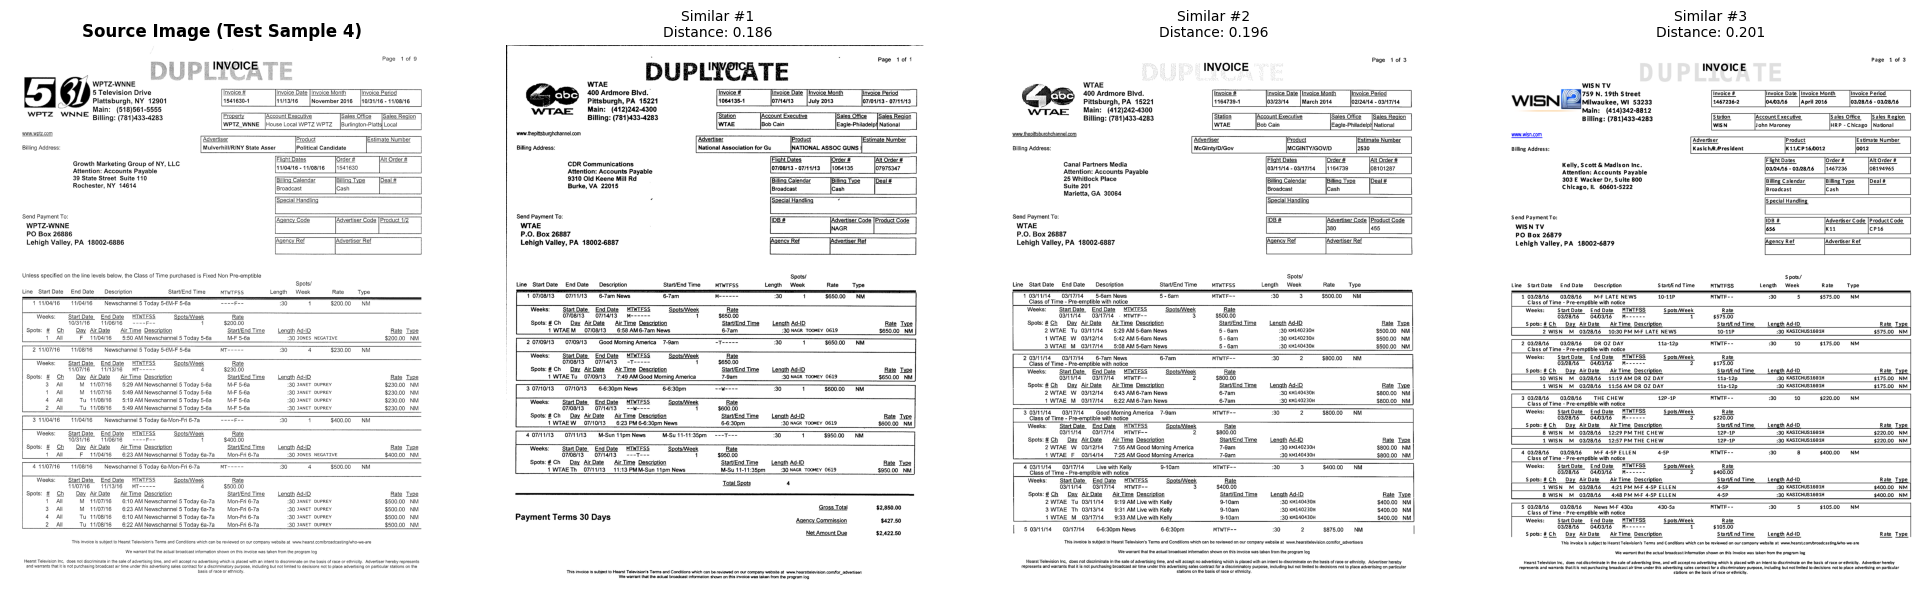


Testing similarity search with test sample 11...

Found 5 similar examples:
  1. Key: fcc_invoices_sample_000205_page0
     Distance: 0.1327
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invoice'
     Attributes Prompt: expected attributes are: {
  "Agency": "House",
  "Advertiser": "John Crawford for State Rep",
  "Gr...
     Image Path: s3://idp-dynamic-few-shot-datasetbucket-zyunmbnz7h2w/fcc_invoices/sample_000205_page0.jpg

  2. Key: fcc_invoices_sample_000103_page0
     Distance: 0.1473
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invoice'
     Attributes Prompt: expected attributes are: {
  "Agency": "NCC - NATIONAL CABLE\nCOMMUNICATION",
  "Advertiser": "ONE N...
     Image Path: s3://idp-dynamic-few-shot-datasetbucket-zyunmbnz7h2w/fcc_invoices/sample_000103_page0.jpg

  3. Key: fcc_invoices_sample_000219_page0
     Distance: 0.1490
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invo

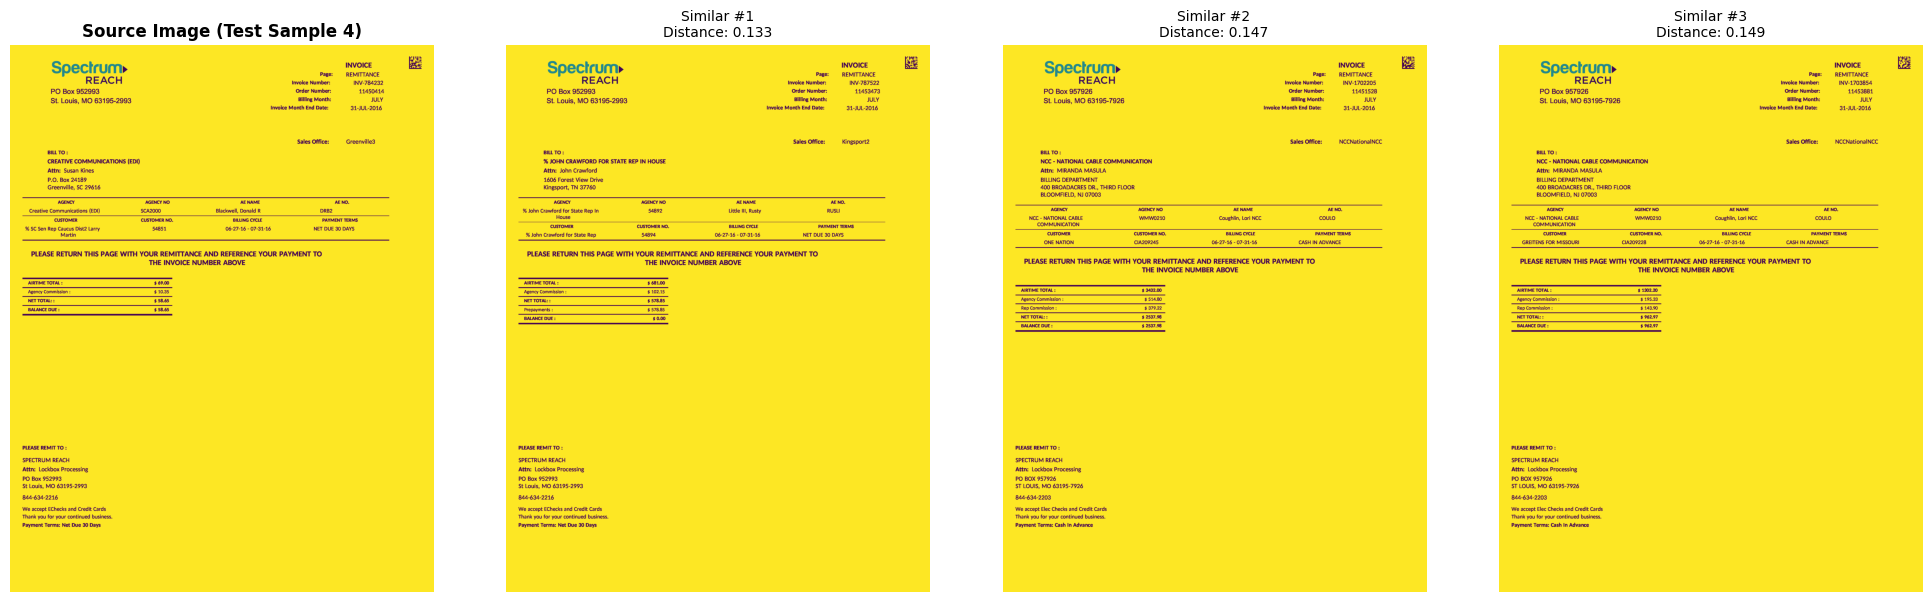


Testing similarity search with test sample 22...

Found 5 similar examples:
  1. Key: fcc_invoices_sample_000151_page1
     Distance: 0.0976
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invoice'
     Attributes Prompt: expected attributes are: {
  "Agency": "STRATEGIC MEDIA SERVICES",
  "Advertiser": "FRIENDS OF ERIK ...
     Image Path: s3://idp-dynamic-few-shot-datasetbucket-zyunmbnz7h2w/fcc_invoices/sample_000151_page1.jpg

  2. Key: fcc_invoices_sample_000217_page0
     Distance: 0.0983
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invoice'
     Attributes Prompt: expected attributes are: {
  "Agency": "KCBS TV",
  "Advertiser": null,
  "GrossTotal": 600.0,
  "Pa...
     Image Path: s3://idp-dynamic-few-shot-datasetbucket-zyunmbnz7h2w/fcc_invoices/sample_000217_page0.jpg

  3. Key: fcc_invoices_sample_000151_page2
     Distance: 0.1015
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invo

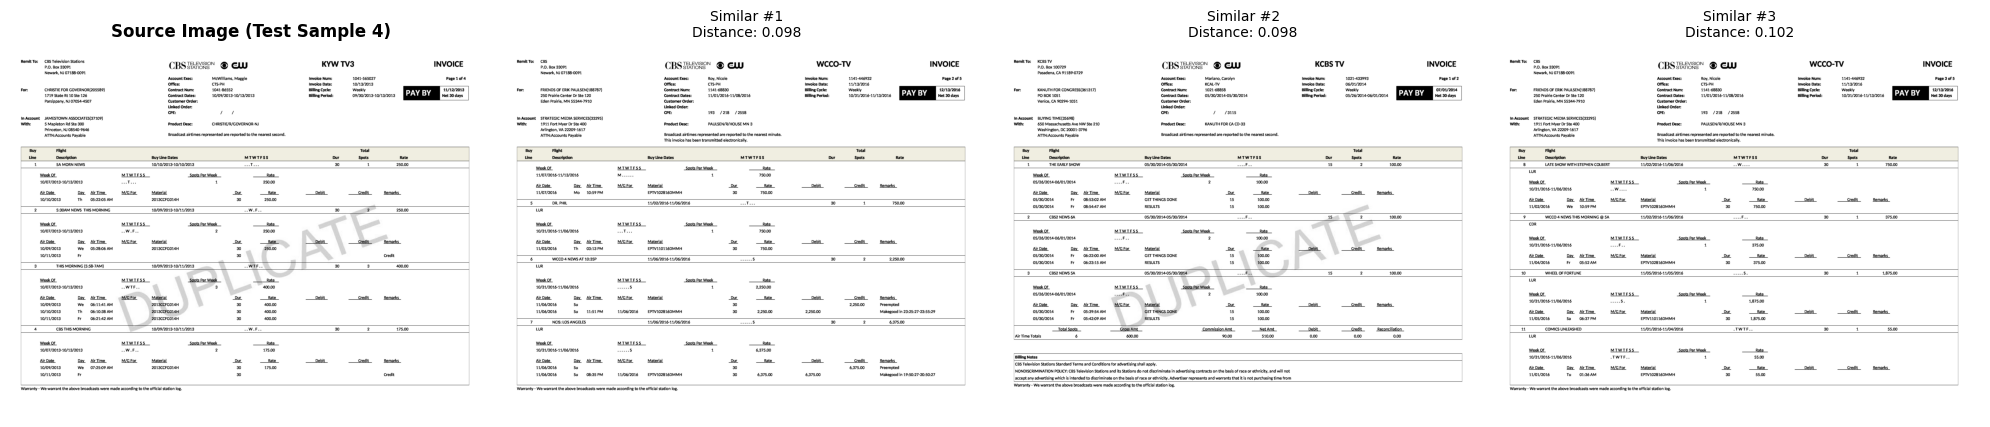


Testing similarity search with test sample 35...

Found 5 similar examples:
  1. Key: fcc_invoices_sample_000082_page0
     Distance: 0.1778
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invoice'
     Attributes Prompt: expected attributes are: {
  "Agency": null,
  "Advertiser": "BoustanylR/Senate",
  "GrossTotal": 10...
     Image Path: s3://idp-dynamic-few-shot-datasetbucket-zyunmbnz7h2w/fcc_invoices/sample_000082_page0.jpg

  2. Key: fcc_invoices_sample_000022_page0
     Distance: 0.1923
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invoice'
     Attributes Prompt: expected attributes are: {
  "Agency": "Strategic Media Services",
  "Advertiser": "Jason Lewis for ...
     Image Path: s3://idp-dynamic-few-shot-datasetbucket-zyunmbnz7h2w/fcc_invoices/sample_000022_page0.jpg

  3. Key: fcc_invoices_sample_000130_page0
     Distance: 0.2008
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invo

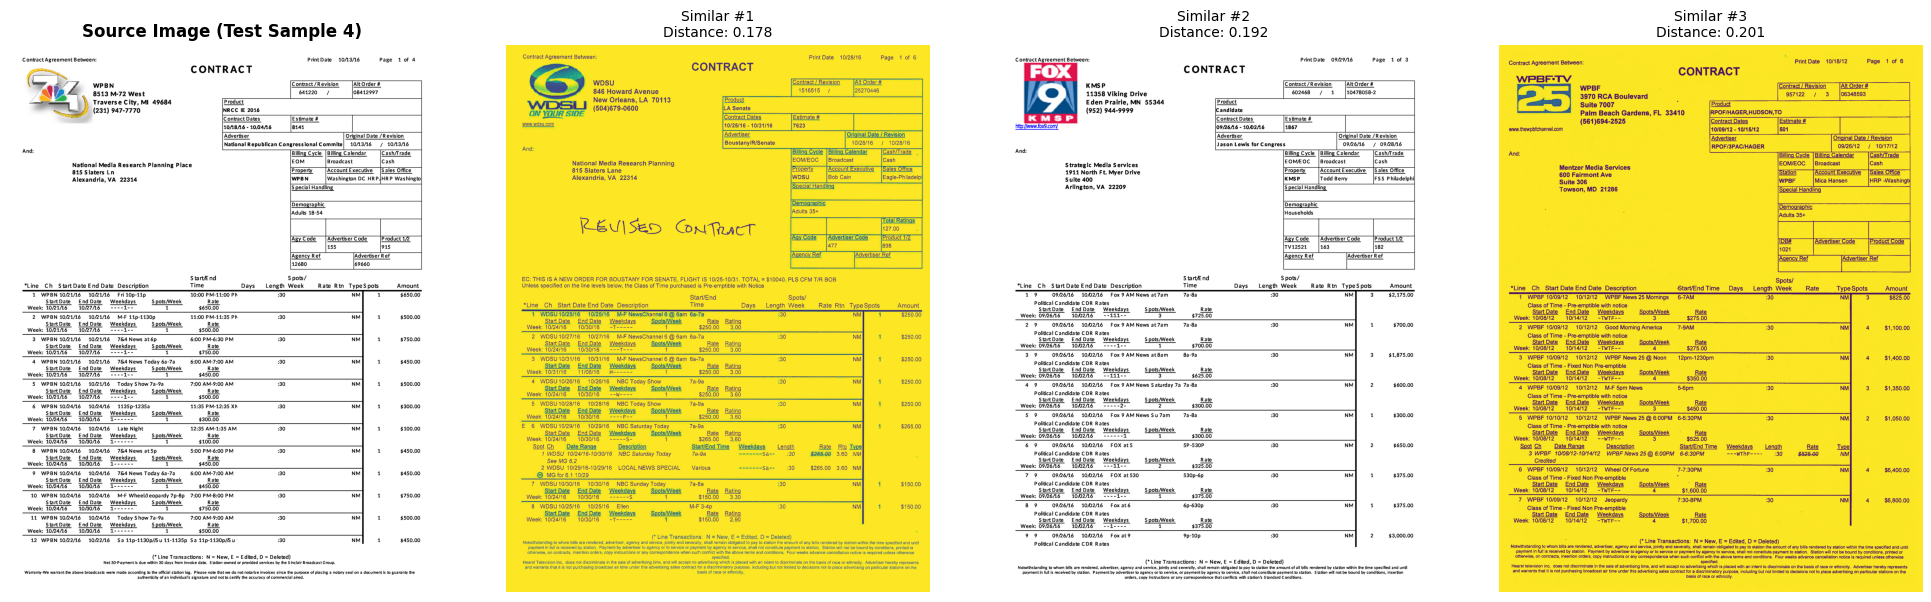


Testing similarity search with test sample 57...

Found 5 similar examples:
  1. Key: fcc_invoices_sample_000034_page1
     Distance: 0.2015
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invoice'
     Attributes Prompt: expected attributes are: {
  "Agency": "Target Enterprises",
  "Advertiser": "Freedom Partners Actio...
     Image Path: s3://idp-dynamic-few-shot-datasetbucket-zyunmbnz7h2w/fcc_invoices/sample_000034_page1.jpg

  2. Key: fcc_invoices_sample_000034_page0
     Distance: 0.2068
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invoice'
     Attributes Prompt: expected attributes are: {
  "Agency": "Target Enterprises",
  "Advertiser": "Freedom Partners Actio...
     Image Path: s3://idp-dynamic-few-shot-datasetbucket-zyunmbnz7h2w/fcc_invoices/sample_000034_page0.jpg

  3. Key: fcc_invoices_sample_000084_page3
     Distance: 0.2322
     Class Label: Invoice
     Class Prompt: This is an example of the class 'Invo

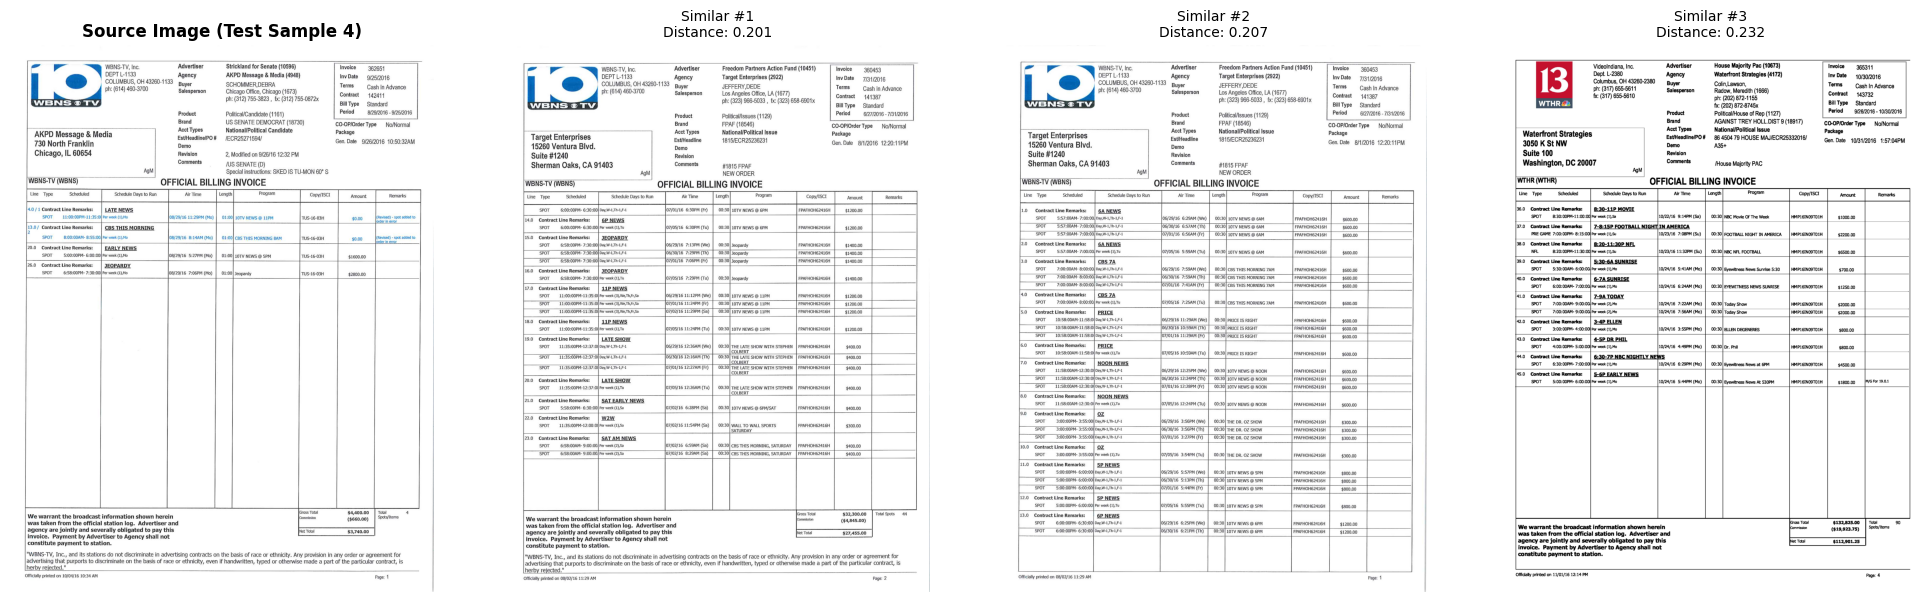

In [ ]:
# Load test split for similarity search verification
test_dataset = load_dataset('csv', data_dir=str(dataset_dir), split='test')
print(f"Loaded test dataset with {len(test_dataset)} samples")

test_indexes = [0, 11, 22, 35, 57] # Random selection, adjust this number based on your needs

if test_dataset and len(test_dataset) > 0:
    for i in test_indexes:
        row = test_dataset[i]

        # Get image files from the CSV row
        image_files_str = row.get('image_files', '')
        if not image_files_str:
            print(f"No image files found for sample {i}")
            continue

        # Parse the image files array (it's stored as a JSON string)
        try:
            image_files = json.loads(image_files_str)
        except json.JSONDecodeError:
            print(f"Failed to parse image_files for sample {i}: {image_files_str}")
            continue
        
        # Use the first image file (or you could process all images)
        if not image_files:
            print(f"Empty image_files array for sample {i}")
            continue

        image_file_path = image_files[0]
        full_image_path = dataset_root_dir / image_file_path
            
        if not full_image_path.exists():
            print(f"Image file not found: {full_image_path}")
            continue
                
        # Load image file as bytes
        image_bytes = get_image_bytes_from_file(full_image_path)

        print(f"\nTesting similarity search with test sample {i}...")

        # Generate embedding for test image
        embedding = bedrock_client.generate_embedding(
            image_source=image_bytes,
            model_id=MODEL_ID,
            dimensions=VECTOR_DIMENSIONS
        )

        # Query S3 Vectors for similar examples
        response = s3vectors_client.query_vectors(
            vectorBucketName=VECTOR_BUCKET_NAME,
            indexName=VECTOR_INDEX_NAME,
            queryVector={"float32": embedding},
            topK=5,
            returnDistance=True,
            returnMetadata=True
        )

        print(f"\nFound {len(response['vectors'])} similar examples:")
        for i, vector in enumerate(response['vectors']):
            distance = vector.get('distance', 'N/A')
            key = vector.get('key', 'N/A')
            metadata = vector.get('metadata', {})
            class_label = metadata.get('classLabel', 'N/A')
            class_prompt = metadata.get('classPrompt', 'N/A')
            attributes_prompt = metadata.get('attributesPrompt', 'N/A')
            image_path = metadata.get('imagePath', 'N/A')
            
            print(f"  {i+1}. Key: {key}")
            print(f"     Distance: {distance:.4f}")
            print(f"     Class Label: {class_label}")
            print(f"     Class Prompt: {class_prompt}")
            print(f"     Attributes Prompt: {attributes_prompt[:100]}...")  # Truncate for readability
            print(f"     Image Path: {image_path}")
            print()

        # Display source image and found similar images
        num_similar = min(3, len(response['vectors']))  # Show top 3 similar images

        print(f'\nDisplaying source image and top {num_similar} similar images from the vector store.')
        display_similar_images(response['vectors'], i, image_bytes)

else:
    print("Test split is empty or could not be loaded")


## 9. Summary and Next Steps

In [ ]:
print("=== Few-shot Dataset Import Summary ===")
print(f"✅ Dataset: FCC Invoices (REALKIE)")
print(f"✅ Samples processed: {samples_to_process - len(failed_samples) if 'samples_to_process' in locals() and 'failed_samples' in locals() else 'N/A'}")
print(f"✅ S3 Vectors Bucket: {VECTOR_BUCKET_NAME}")
print(f"✅ S3 Vectors Index: {VECTOR_INDEX_NAME}")
print(f"✅ Images stored in: s3://{DATASET_BUCKET}/fcc_invoices/")
print(f"✅ Embedding Model: {MODEL_ID}")
print(f"✅ Similarity search verified")

print("\n=== Next Steps ===")
print("1. Configure your IDP extraction to use the dynamic few-shot Lambda ARN")
print("2. Test document processing with few-shot examples and the Test Suite available in IDP to compare results")
print("3. Import your own dataset using the structure provided in this notebook")